In [9]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from sqlalchemy.exc import OperationalError


def postgres_url(host: str) -> str:
    return (
        f"postgresql+psycopg2://{os.getenv('PGUSER', 'analytics')}:"
        f"{os.getenv('PGPASSWORD', 'analytics')}@{host}:"
        f"{os.getenv('PGPORT', '5432')}/{os.getenv('PGDATABASE', 'oil_analytics')}"
    )


hosts = [os.getenv('PGHOST'), 'postgres', 'localhost']
hosts = list(dict.fromkeys(host for host in hosts if host))

last_error = None
for host in hosts:
    try:
        engine = create_engine(postgres_url(host))
        with engine.connect() as conn:
            conn.execute(text('select 1'))
        print(f'Connected to PostgreSQL at {host}')
        break
    except OperationalError as exc:
        last_error = exc
else:
    raise last_error

sns.set_theme(style='whitegrid')

Connected to PostgreSQL at localhost


In [10]:
production = pd.read_sql('select * from mart_production order by date', engine)
well_kpis = pd.read_sql('select * from mart_well_kpis order by rank_by_oil', engine)
forecast = pd.read_sql('select * from mart_ml_oil_forecast order by date, well_id', engine)
failures = pd.read_sql('select * from mart_failures order by timestamp', engine)
logistics = pd.read_sql('select * from mart_logistics order by optimization_score', engine)
quality = pd.read_sql('select * from data_quality_report order by table_name', engine)

display(quality)
display(well_kpis.head())

,table_name,row_count,null_pct,outlier_count
0,deliveries,30,0.0,1
1,drivers,5,0.0,0
2,oil_stations,20,0.0,1
3,production,150,4.0,150
4,pump_failures,3,0.0,0
5,pumps,5,0.0,0
6,pump_sensors,72,0.0,7
7,vehicles,5,0.0,0
8,wells,5,0.0,0
9,well_targets,90,0.0,0


,well_id,name,field_name,region,operator,status,avg_oil_ton,total_oil_ton,downtime_pct,avg_pressure,avg_temperature,avg_energy_kwh,rank_by_oil
0,1,Well-101,Severo-Ural,Khanty-Mansi,UralOil,active,213.150000,6394.500,2.013889,120.543333,88.206667,7458.833333,1
1,5,Well-305,Zapad-Field,Tomsk,RosDrill,active,198.430000,5952.900,1.819444,119.426667,86.800000,7240.166667,2
2,2,Well-102,Severo-Ural,Khanty-Mansi,UralOil,active,185.816667,5574.500,3.027778,115.306667,84.486667,6794.166667,3
3,3,Well-203,Vostok-Field,Yamalo-Nenets,GazPromTech,maintenance,121.696667,3650.900,8.111111,107.160000,79.433333,5285.166667,4
4,4,Well-304,Zapad-Field,Tomsk,RosDrill,suspended,4.037500,121.125,100.000000,117.350000,85.700000,2294.375000,5


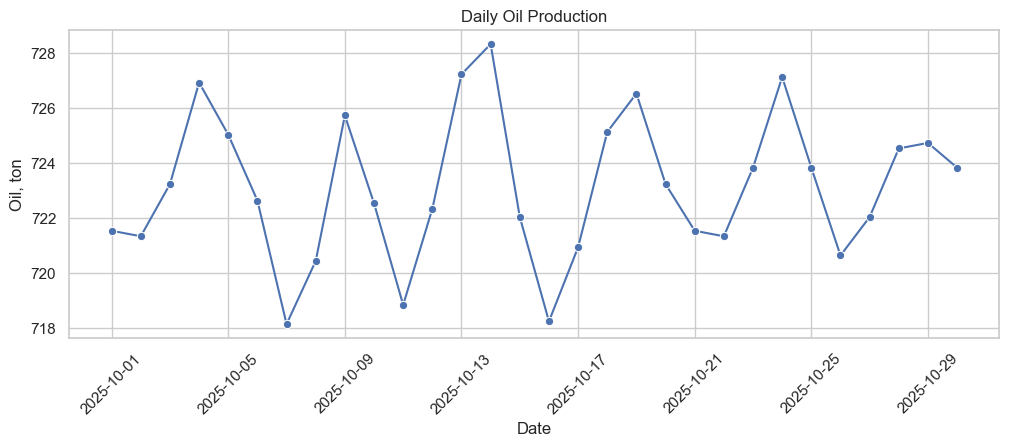

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=production, x='date', y='total_oil_ton', marker='o', ax=ax)
ax.set_title('Daily Oil Production')
ax.set_xlabel('Date')
ax.set_ylabel('Oil, ton')
plt.xticks(rotation=45)
plt.show()

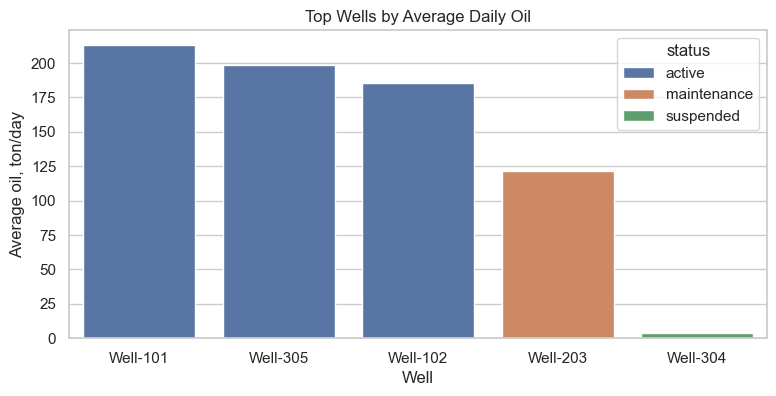

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=well_kpis, x='name', y='avg_oil_ton', hue='status', ax=ax)
ax.set_title('Top Wells by Average Daily Oil')
ax.set_xlabel('Well')
ax.set_ylabel('Average oil, ton/day')
plt.show()

/var/folders/k5/9w9q91gs7sl0khdrbh87y7mr0000gn/T/ipykernel_99661/1388435313.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = effect.pivot_table(


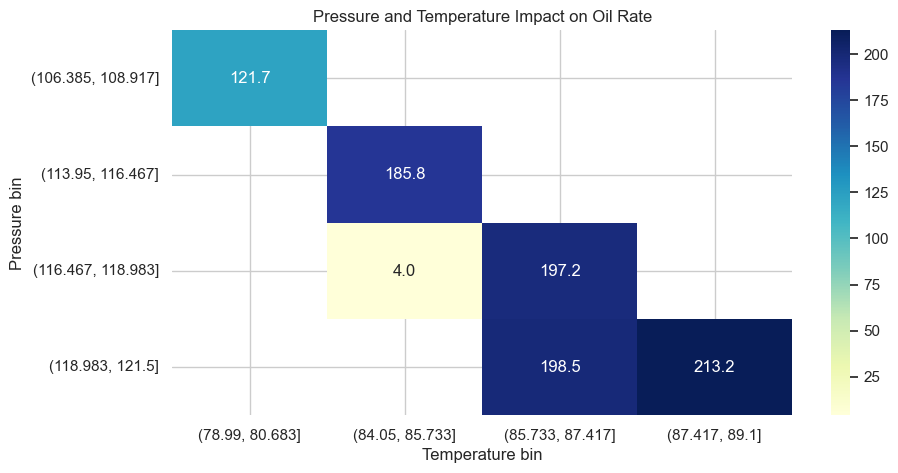

In [13]:
effect = pd.read_sql('select oil_ton, pressure, temperature from mart_pressure_temperature_effect', engine)
heatmap_data = effect.pivot_table(
    values='oil_ton',
    index=pd.cut(effect['pressure'], bins=6),
    columns=pd.cut(effect['temperature'], bins=6),
    aggfunc='mean',
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax)
ax.set_title('Pressure and Temperature Impact on Oil Rate')
ax.set_xlabel('Temperature bin')
ax.set_ylabel('Pressure bin')
plt.show()

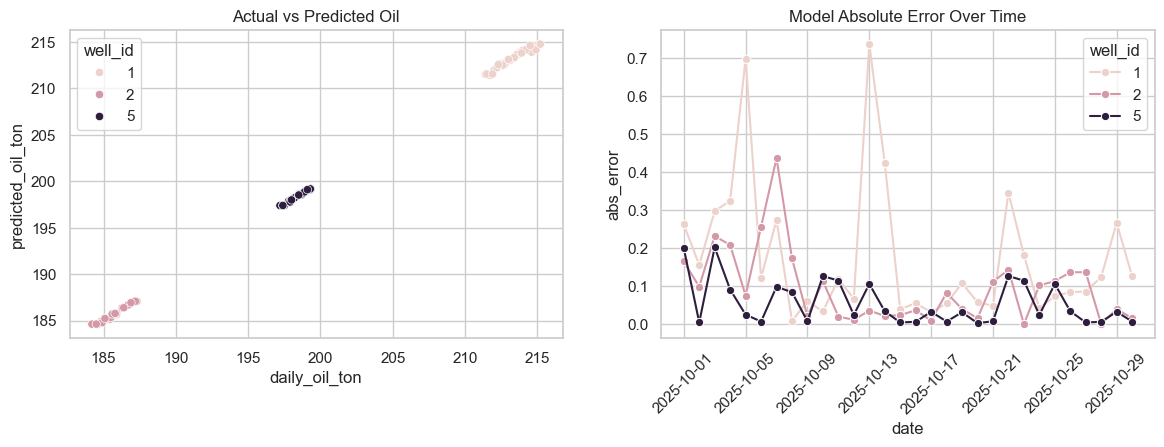

,model_mae,model_rmse
0,0.166126,0.250723


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.scatterplot(data=forecast, x='daily_oil_ton', y='predicted_oil_ton', hue='well_id', ax=axes[0])
axes[0].set_title('Actual vs Predicted Oil')
sns.lineplot(data=forecast, x='date', y='abs_error', hue='well_id', marker='o', ax=axes[1])
axes[1].set_title('Model Absolute Error Over Time')
plt.xticks(rotation=45)
plt.show()
forecast[['model_mae', 'model_rmse']].head(1)

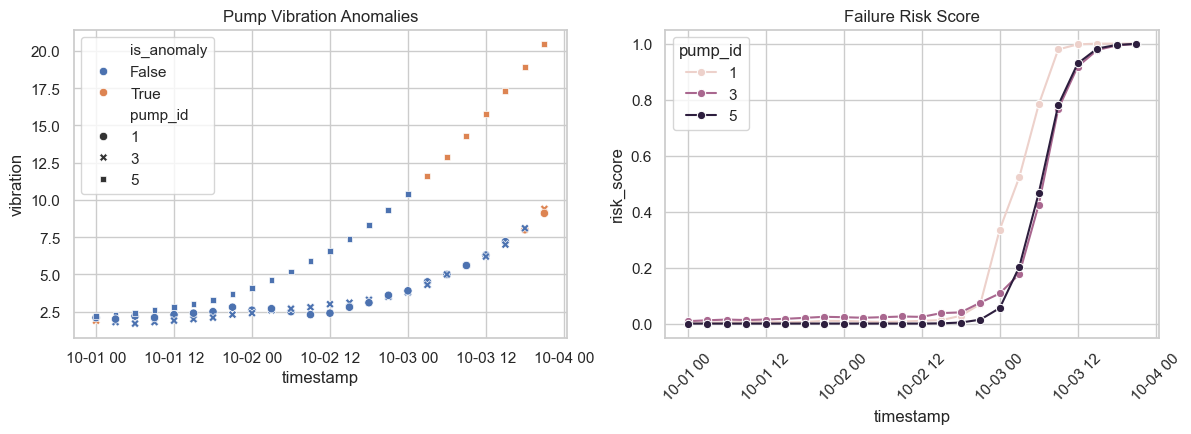

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.scatterplot(data=failures, x='timestamp', y='vibration', hue='is_anomaly', style='pump_id', ax=axes[0])
axes[0].set_title('Pump Vibration Anomalies')
sns.lineplot(data=failures, x='timestamp', y='risk_score', hue='pump_id', marker='o', ax=axes[1])
axes[1].set_title('Failure Risk Score')
plt.xticks(rotation=45)
plt.show()

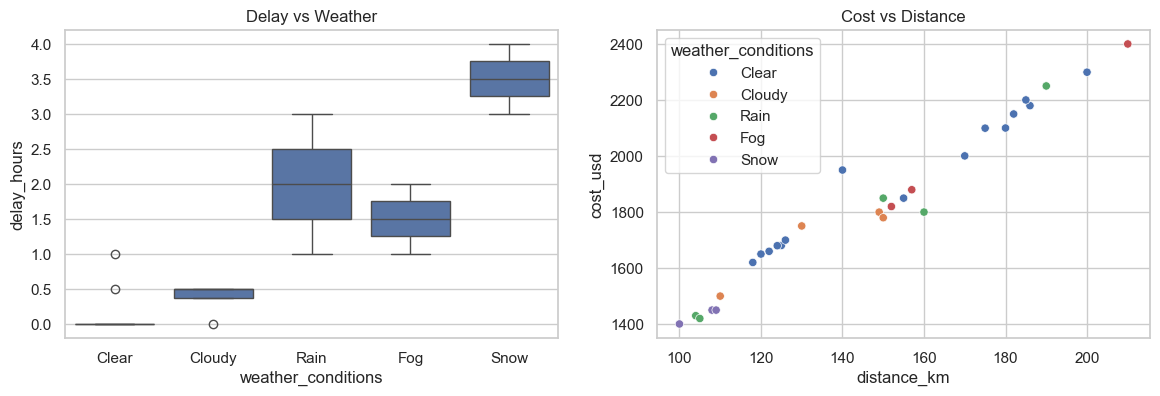

,route,driver_id,cost_per_km,delay_hours,optimization_score
0,Base-Khanty -> Station-27,1,11.500000,0.0,11.500000
1,Base-Khanty -> Station-01,1,11.669444,0.0,11.669444
2,Base-Khanty -> Station-19,1,11.722581,0.0,11.722581
3,Base-Khanty -> Station-09,4,11.770000,0.0,11.770000
4,Base-Khanty -> Station-15,4,11.816484,0.0,11.816484
5,Base-Khanty -> Station-06,1,11.895946,0.0,11.895946
6,Base-Tomsk -> Station-12,2,11.935484,0.0,11.935484
7,Base-Tomsk -> Station-24,2,12.080537,0.0,12.080537
8,Base-Tyumen -> Station-13,3,13.447200,0.0,13.447200
9,Base-Tyumen -> Station-25,3,13.492063,0.0,13.492063


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=logistics, x='weather_conditions', y='delay_hours', ax=axes[0])
axes[0].set_title('Delay vs Weather')
sns.scatterplot(data=logistics, x='distance_km', y='cost_usd', hue='weather_conditions', ax=axes[1])
axes[1].set_title('Cost vs Distance')
plt.show()
logistics[['route', 'driver_id', 'cost_per_km', 'delay_hours', 'optimization_score']].head(10)